INVERTER 32nm CMOS data

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras import backend as K
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from joblib import load

K.clear_session()

plots_dir = "../../../../../figures/CMOS/32nm/NOT/02_training_outputs/"

# Loading scalers
scaler_x = joblib.load('../../../../../data/processed/CMOS/32nm/NOT/scaler_x.pkl')
scaler_y = joblib.load('../../../../../data/processed/CMOS/32nm/NOT/scaler_y.pkl')

# Loading split data

X_train_sc = pd.read_csv('../../../../../data/processed/CMOS/32nm/NOT/X_train_sc.csv')
X_val_sc   = pd.read_csv('../../../../../data/processed/CMOS/32nm/NOT/X_val_sc.csv')
Xte_sc     = pd.read_csv('../../../../../data/processed/CMOS/32nm/NOT/X_test_sc.csv')

y_train_sc = pd.read_csv('../../../../../data/processed/CMOS/32nm/NOT/y_train_sc.csv')
y_val_sc   = pd.read_csv('../../../../../data/processed/CMOS/32nm/NOT/y_val_sc.csv')
yte_sc     = pd.read_csv('../../../../../data/processed/CMOS/32nm/NOT/y_test_sc.csv')

print(f"Training set loaded: {X_train_sc.shape}")
print(f"Validation set loaded: {X_val_sc.shape}")
print(f"Test set loaded: {Xte_sc.shape}")

I0000 00:00:1779886254.235457   14842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779886254.235956   14842 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779886254.276056   14842 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779886255.499087   14842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Training set loaded: (64204, 7)
Validation set loaded: (31624, 7)
Test set loaded: (31943, 7)


### Plot Functions

In [2]:
variables = ['TPHL', 'TPLH', 'CORRENT']

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

def scatter_plot_multi_output_regression_results(y_predi, y_real, target_names, fname, subtitle=None):
    y_pred = np.array(y_predi)
    y_true = np.array(y_real)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if subtitle:
        fig.suptitle(subtitle, fontsize=13, fontweight='bold', y=1.02)
    
    for i in range(3):
        ax = axes[i]
        
        sns.scatterplot(x=y_true[:, i], y=y_pred[:, i], ax=ax, 
                        alpha=0.5, color='royalblue', edgecolor=None)
        
        low = min(y_true[:, i].min(), y_pred[:, i].min())
        high = max(y_true[:, i].max(), y_pred[:, i].max())
        ax.plot([low, high], [low, high], color='red', linestyle='--', lw=2, label='Ideal')
        

        r2 = r2_score(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        
        ax.set_title(f'{target_names[i]}\n$R^2 = {r2:.3f}$ | $RMSE = {rmse:.3f}$')
        ax.set_xlabel('Valores Reais ($y_{true}$)')
        ax.set_ylabel(r'Predições ($\hat{y}$)')
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0: ax.legend()

    plt.tight_layout()
    plt.savefig(f"{plots_dir}{fname}.png", dpi=300, bbox_inches='tight') 
    plt.show()

def kde_plot_multi_output_regression_results(y_pred, y_real, target_names, fname, subtitle=None):
    y_pred_np = np.array(y_pred)
    y_val_np  = np.array(y_real)

    for i, var in enumerate(target_names):
        fig, ax = plt.subplots(1, 1, figsize=(10, 7))

        sns.kdeplot(data=y_pred_np[:, i], label='predicted', ax=ax, color='royalblue')
        sns.kdeplot(data=y_val_np[:, i],  label='true',      ax=ax, color='red')

        title = f'{subtitle}, {var}' if subtitle else var
        ax.set_title(title)
        ax.legend()

        plt.savefig(f"{plots_dir}/{fname}_{var}.png")
        plt.show()
        plt.close()

# Multi-layer Perceptron (MPL)
Neural network for supervised learning

Idea:
- Single-output model approach (Predicting one output at a time)
- Multi-output model approach (Predicting three outputs at the same time)

Metrics
- R² score (coefficient of determination) regression score function
- RMSE and MSE error metrics

In [3]:
scores = {}

In [4]:
def score(model, X, y, target_name, target_variable, target_set):
    pred = model.predict(X)
    r2 = r2_score(y, pred)
    rmse = root_mean_squared_error(y, pred)
    mse = mean_squared_error(y, pred)

    scores[target_name, target_variable, target_set] = {
        'r2': r2,
        'rmse': rmse,
        'mse': mse,
    }
    return scores[target_name, target_variable, target_set]

## Multi-layer Perceptron for Regression using Scikit-Learn

In [5]:
mlp_regressor= MLPRegressor(activation='relu',
                            solver = 'adam',
                            max_iter=500,
                            shuffle=True,
                            validation_fraction=0.1,
                            n_iter_no_change=10,
                            hidden_layer_sizes=(100, ),
                            early_stopping = True,
                            random_state=42,
                            verbose=True
                           )

In [6]:
joblib.dump(mlp_regressor, "/home/eduarda/Repos/jupyter_ic/models/mlp_regressor_SKL_untrained.joblib")

['/home/eduarda/Repos/jupyter_ic/models/mlp_regressor_SKL_untrained.joblib']

### Single-output models

In [7]:
#### Predicting TPHL

In [8]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc['tphl'])

Iteration 1, loss = 0.13839182
Validation score: 0.925934
Iteration 2, loss = 0.02148583
Validation score: 0.973076
Iteration 3, loss = 0.00898416
Validation score: 0.988601
Iteration 4, loss = 0.00369022
Validation score: 0.994741
Iteration 5, loss = 0.00209567
Validation score: 0.996627
Iteration 6, loss = 0.00147060
Validation score: 0.997264
Iteration 7, loss = 0.00112573
Validation score: 0.998109
Iteration 8, loss = 0.00088707
Validation score: 0.998481
Iteration 9, loss = 0.00072745
Validation score: 0.998747
Iteration 10, loss = 0.00060615
Validation score: 0.998929
Iteration 11, loss = 0.00051324
Validation score: 0.999098
Iteration 12, loss = 0.00044589
Validation score: 0.999250
Iteration 13, loss = 0.00039501
Validation score: 0.999224
Iteration 14, loss = 0.00036109
Validation score: 0.999381
Iteration 15, loss = 0.00032303
Validation score: 0.999411
Iteration 16, loss = 0.00029015
Validation score: 0.999487
Iteration 17, loss = 0.00027094
Validation score: 0.999504
Iterat

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [9]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.00018926437785591515


In [10]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [11]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc['tphl'])

0.9996754255715159

In [12]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tphl'], y_pred_sc)
mse = mean_squared_error(y_val_sc['tphl'], y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.01804582762444334
clf: MLP, MSE 0.00032565189465112243


In [13]:
score(mlp_regressor, X_val_sc, y_val_sc['tphl'], 'mlp_S_SKL', 'tphl', 'val')

{'r2': 0.9996754255715159,
 'rmse': 0.01804582762444334,
 'mse': 0.00032565189465112243}

In [14]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [15]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc['tphl'])

0.9996568242502238

In [16]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tphl'], y_test_pred_sc)
mse = mean_squared_error(yte_sc['tphl'], y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.01864515971001046
clf: MLP, MSE 0.00034764198061179737


In [17]:
score(mlp_regressor, Xte_sc, yte_sc['tphl'], 'mlp_S_SKL', 'tphl', 'test')

{'r2': 0.9996568242502238,
 'rmse': 0.01864515971001046,
 'mse': 0.00034764198061179737}

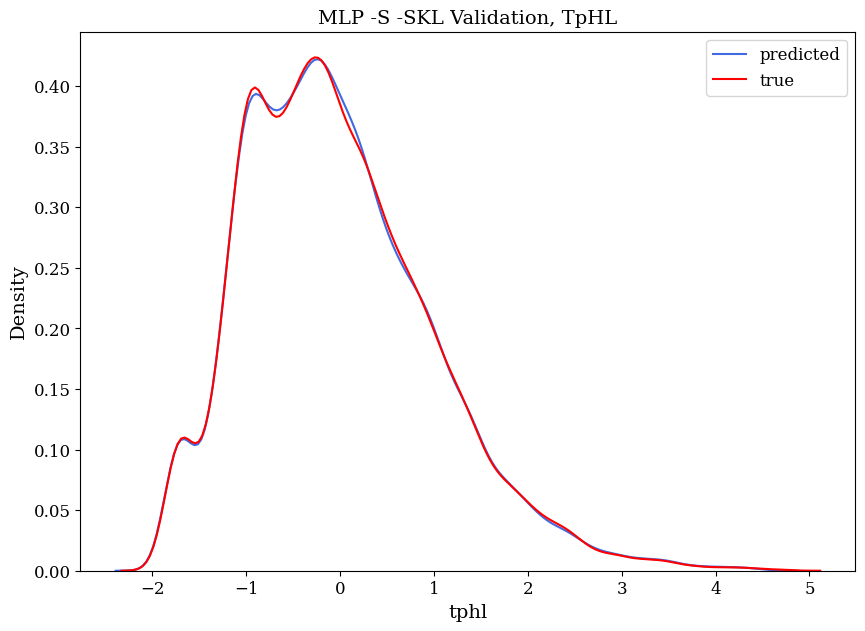

In [18]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_TPHL.png")
plt.show()
plt.close()

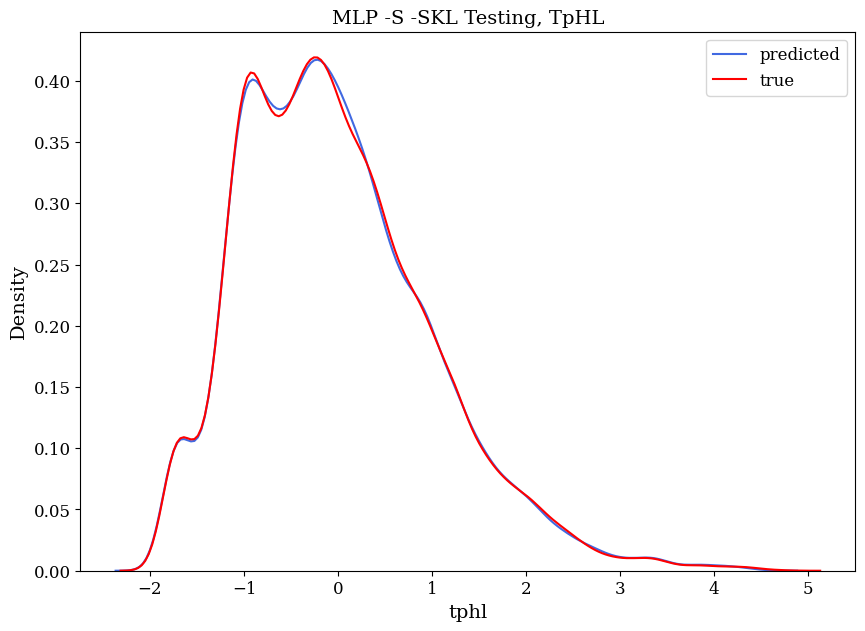

In [19]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_TPHL.png")
plt.show()
plt.close()

#### Predicting TPLH

In [20]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc['tplh'])

Iteration 1, loss = 0.14586533
Validation score: 0.890270
Iteration 2, loss = 0.03406379
Validation score: 0.964349
Iteration 3, loss = 0.01156348
Validation score: 0.986576
Iteration 4, loss = 0.00463336
Validation score: 0.993774
Iteration 5, loss = 0.00241561
Validation score: 0.996269
Iteration 6, loss = 0.00154544
Validation score: 0.997399
Iteration 7, loss = 0.00108161
Validation score: 0.998058
Iteration 8, loss = 0.00082937
Validation score: 0.998508
Iteration 9, loss = 0.00065984
Validation score: 0.998835
Iteration 10, loss = 0.00056786
Validation score: 0.998925
Iteration 11, loss = 0.00051212
Validation score: 0.999027
Iteration 12, loss = 0.00047634
Validation score: 0.999073
Iteration 13, loss = 0.00045176
Validation score: 0.999143
Iteration 14, loss = 0.00042509
Validation score: 0.999212
Iteration 15, loss = 0.00041082
Validation score: 0.999183
Iteration 16, loss = 0.00040025
Validation score: 0.999235
Iteration 17, loss = 0.00039185
Validation score: 0.999271
Iterat

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [21]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.0003663888587580963


In [22]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [23]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc['tplh'])

0.9992730086252184

In [24]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tplh'], y_pred_sc)
mse = mean_squared_error(y_val_sc['tplh'], y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.026609033490751256
clf: MLP, MSE 0.000708040663311922


In [25]:
score(mlp_regressor, X_val_sc, y_val_sc['tplh'], 'mlp_S_SKL', 'tplh', 'val')

{'r2': 0.9992730086252184,
 'rmse': 0.026609033490751256,
 'mse': 0.000708040663311922}

In [26]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [27]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc['tplh'])

0.9992687983939565

In [28]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tplh'], y_test_pred_sc)
mse = mean_squared_error(yte_sc['tplh'], y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.027004031564189256
clf: MLP, MSE 0.0007292177207197297


In [29]:
score(mlp_regressor, Xte_sc, yte_sc['tplh'], 'mlp_S_SKL', 'tplh', 'test')

{'r2': 0.9992687983939565,
 'rmse': 0.027004031564189256,
 'mse': 0.0007292177207197297}

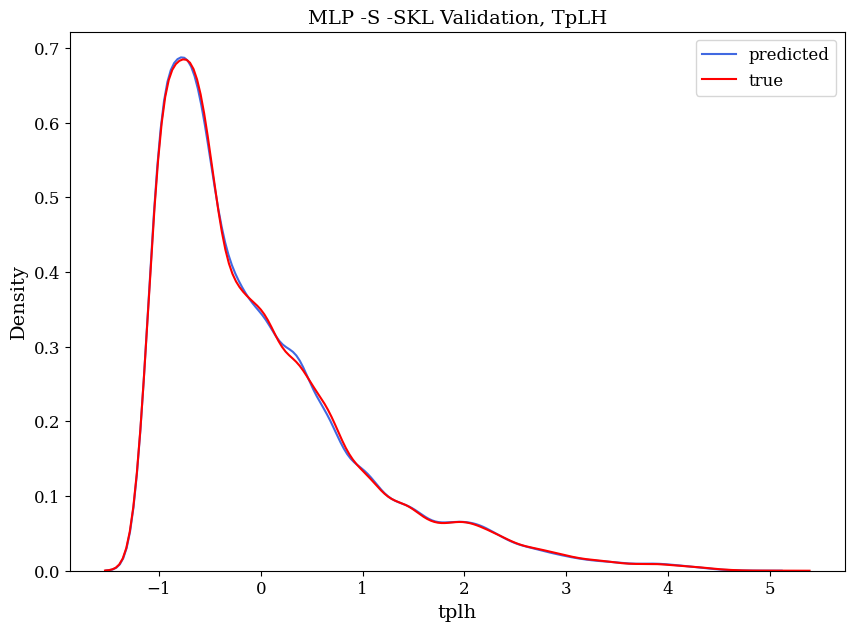

In [30]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpLH')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_TPLH.png")
plt.show()
plt.close()

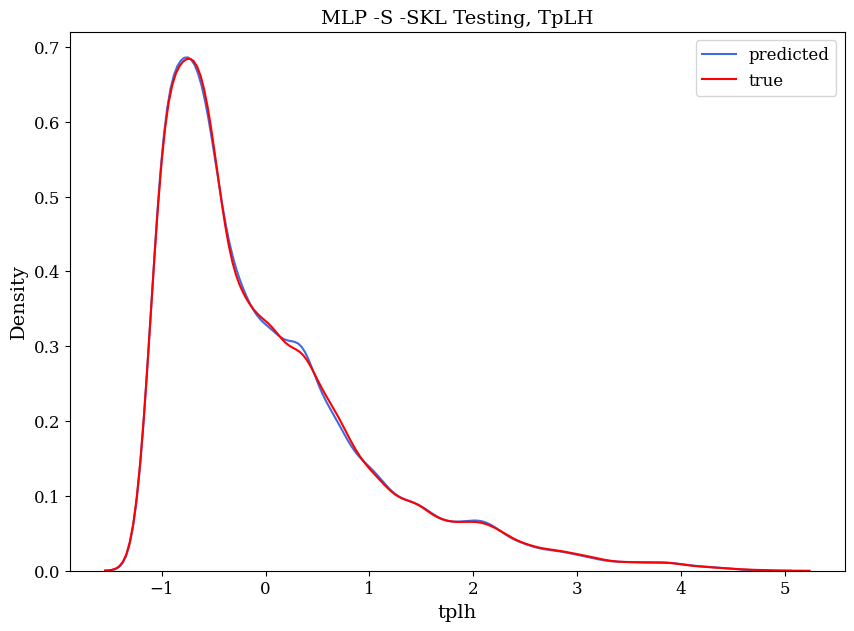

In [31]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpLH')
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_TPLH.png")
ax.legend()
plt.show()
plt.close()

#### Predicting Energy

In [32]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc['energy'])

Iteration 1, loss = 0.15574496
Validation score: 0.909373
Iteration 2, loss = 0.02574304
Validation score: 0.970900
Iteration 3, loss = 0.01003726
Validation score: 0.986049
Iteration 4, loss = 0.00533191
Validation score: 0.991537
Iteration 5, loss = 0.00349082
Validation score: 0.993865
Iteration 6, loss = 0.00265745
Validation score: 0.995183
Iteration 7, loss = 0.00221234
Validation score: 0.995676
Iteration 8, loss = 0.00192883
Validation score: 0.996361
Iteration 9, loss = 0.00171626
Validation score: 0.996768
Iteration 10, loss = 0.00155594
Validation score: 0.997048
Iteration 11, loss = 0.00144120
Validation score: 0.997187
Iteration 12, loss = 0.00135277
Validation score: 0.997332
Iteration 13, loss = 0.00126910
Validation score: 0.997544
Iteration 14, loss = 0.00121644
Validation score: 0.997616
Iteration 15, loss = 0.00117698
Validation score: 0.997791
Iteration 16, loss = 0.00114930
Validation score: 0.997846
Iteration 17, loss = 0.00109807
Validation score: 0.997725
Iterat

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [33]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.0009347708717357159


In [34]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [35]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc['energy'])

0.9981770230257411

In [36]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['energy'], y_pred_sc)
mse = mean_squared_error(y_val_sc['energy'], y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.042668640276935066
clf: MLP, MSE 0.0018206128630824856


In [37]:
score(mlp_regressor, X_val_sc, y_val_sc['energy'], 'mlp_S_SKL', 'corrent', 'val')

{'r2': 0.9981770230257411,
 'rmse': 0.042668640276935066,
 'mse': 0.0018206128630824856}

In [38]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [39]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc['energy'])

0.9981936869983989

In [40]:
# Testing error
rmse = root_mean_squared_error(yte_sc['energy'], y_test_pred_sc)
mse = mean_squared_error(yte_sc['energy'], y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.04258214838798361
clf: MLP, MSE 0.0018132393613362553


In [41]:
score(mlp_regressor, Xte_sc, yte_sc['energy'], 'mlp_S_SKL', 'corrent', 'test')

{'r2': 0.9981936869983989,
 'rmse': 0.04258214838798361,
 'mse': 0.0018132393613362553}

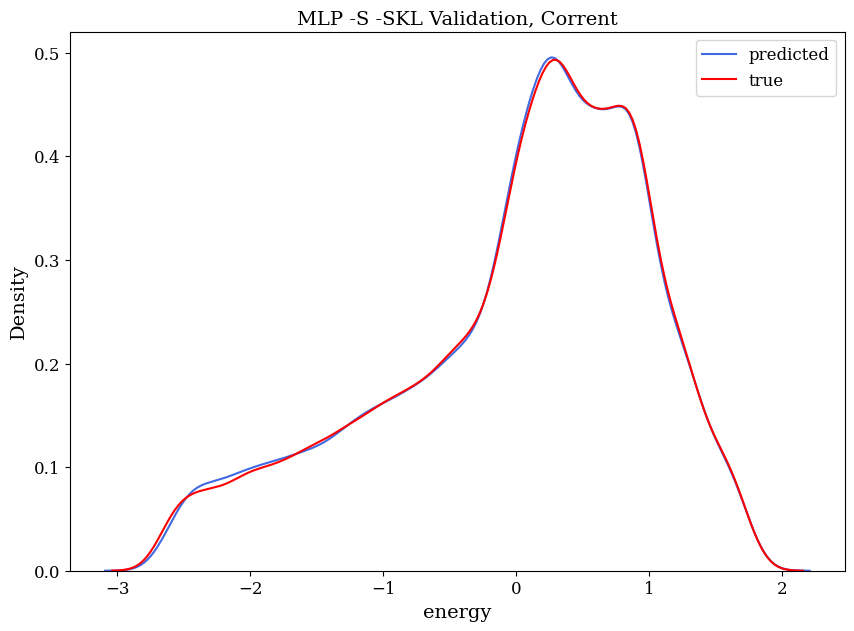

In [42]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['energy'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, Corrent')
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_CORRENT.png")
ax.legend()
plt.show()
plt.close()

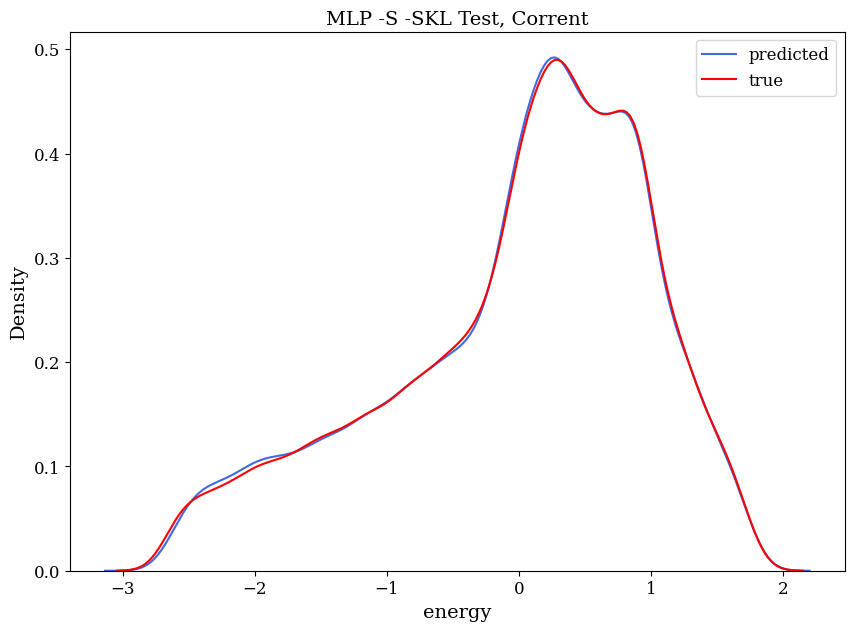

In [43]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['energy'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Test, Corrent')
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_CORRENT.png")
ax.legend()
plt.show()
plt.close()

### Multi-output model

In [44]:
# Training
mlp_regressor.fit(X_train_sc, y_train_sc)

Iteration 1, loss = 0.16712254
Validation score: 0.894033
Iteration 2, loss = 0.03613796
Validation score: 0.951400
Iteration 3, loss = 0.01721455
Validation score: 0.976770
Iteration 4, loss = 0.00868187
Validation score: 0.987277
Iteration 5, loss = 0.00502736
Validation score: 0.991907
Iteration 6, loss = 0.00338936
Validation score: 0.994241
Iteration 7, loss = 0.00250339
Validation score: 0.995484
Iteration 8, loss = 0.00200626
Validation score: 0.996195
Iteration 9, loss = 0.00168647
Validation score: 0.996847
Iteration 10, loss = 0.00145574
Validation score: 0.997211
Iteration 11, loss = 0.00129468
Validation score: 0.997545
Iteration 12, loss = 0.00117280
Validation score: 0.997764
Iteration 13, loss = 0.00108553
Validation score: 0.997895
Iteration 14, loss = 0.00101712
Validation score: 0.998084
Iteration 15, loss = 0.00095002
Validation score: 0.998195
Iteration 16, loss = 0.00089404
Validation score: 0.998253
Iteration 17, loss = 0.00085818
Validation score: 0.998288
Iterat

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [45]:
print(mlp_regressor.out_activation_)
print(mlp_regressor.loss_)

identity
0.0006995285373070134


In [46]:
# Validation
y_pred_sc = mlp_regressor.predict(X_val_sc)

In [47]:
# Validation R² score
mlp_regressor.score(X_val_sc, y_val_sc)

0.9986436370559426

In [48]:
# Validation error
rmse = root_mean_squared_error(y_val_sc, y_pred_sc)
mse = mean_squared_error(y_val_sc, y_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.03502012522018573
clf: MLP, MSE 0.001348017280905507


In [49]:
score(mlp_regressor, X_val_sc, y_val_sc, 'mlp_M_SKL', 'all', 'val')

{'r2': 0.9986436370559426,
 'rmse': 0.03502012522018573,
 'mse': 0.001348017280905507}

In [50]:
# Testing
y_test_pred_sc = mlp_regressor.predict(Xte_sc)

In [51]:
# Testing R² score
mlp_regressor.score(Xte_sc, yte_sc)

0.9986319413767003

In [52]:
# Testing error
rmse = root_mean_squared_error(yte_sc, y_test_pred_sc)
mse = mean_squared_error(yte_sc, y_test_pred_sc)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.0354252556631117
clf: MLP, MSE 0.0013732150212694774


In [53]:
score(mlp_regressor, Xte_sc, yte_sc, 'mlp_M_SKL', 'all', 'test')

{'r2': 0.9986319413767003,
 'rmse': 0.0354252556631117,
 'mse': 0.0013732150212694774}

In [54]:
#scatter_plot_multi_output_regression_results(y_pred_sc, y_val_sc, variables, "MLP_M_SKL_VAL_ALL_SCATTER", "MLP_M_SKL_VAL_ALL_SCATTER")

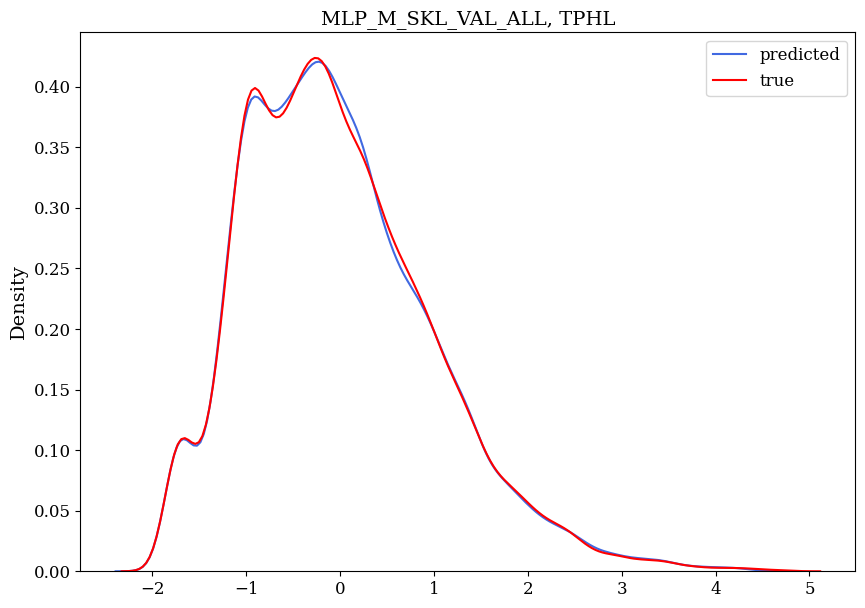

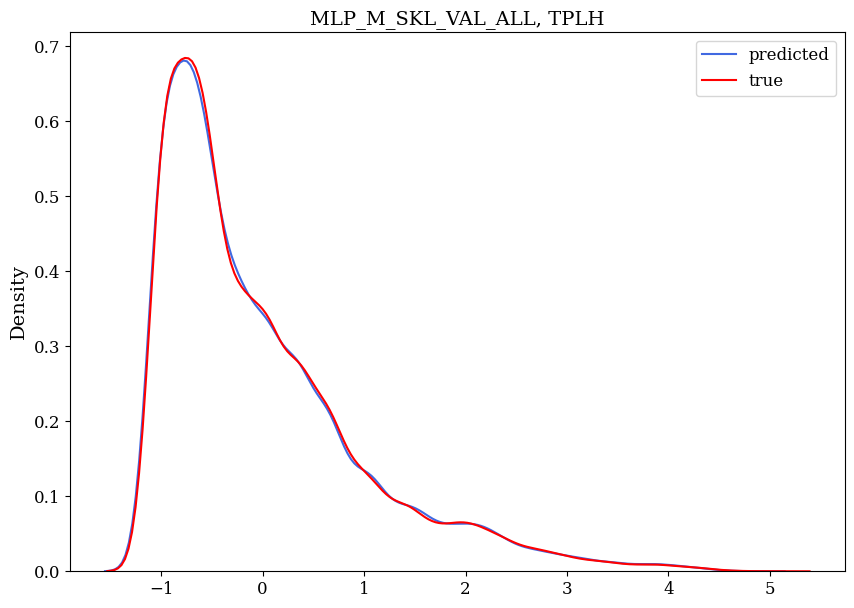

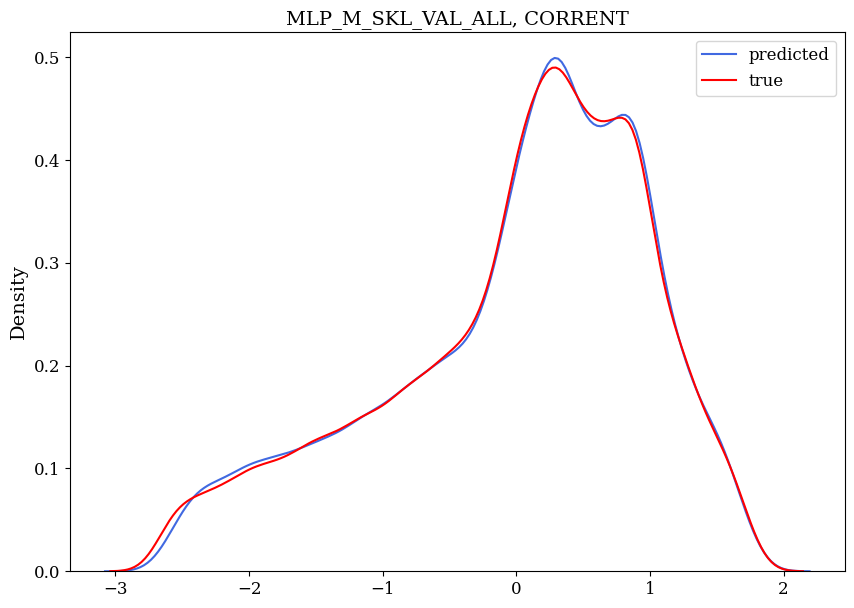

In [55]:
kde_plot_multi_output_regression_results(y_pred_sc, y_val_sc, variables, "MLP_M_SKL_VAL_ALL", "MLP_M_SKL_VAL_ALL")

In [56]:
# scatter_plot_multi_output_regression_results(y_test_pred_sc, yte_sc, variables, "MLP_M_SKL_TEST_ALL_SCATTER", "MLP_M_SKL_TEST_ALL_SCATTER")

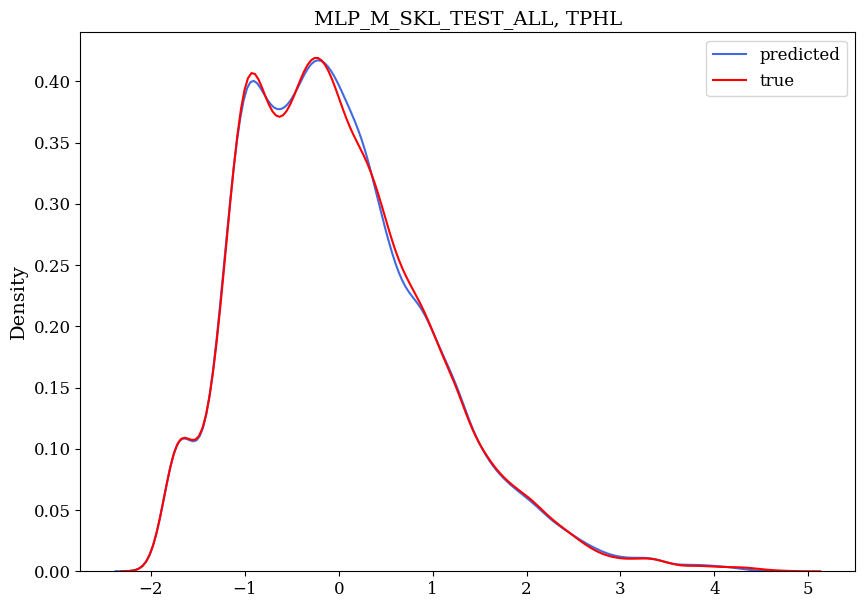

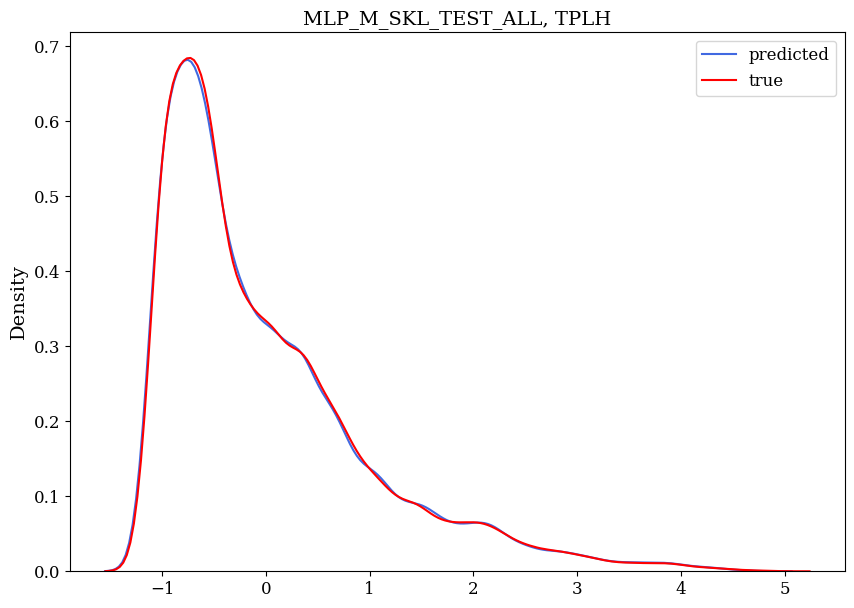

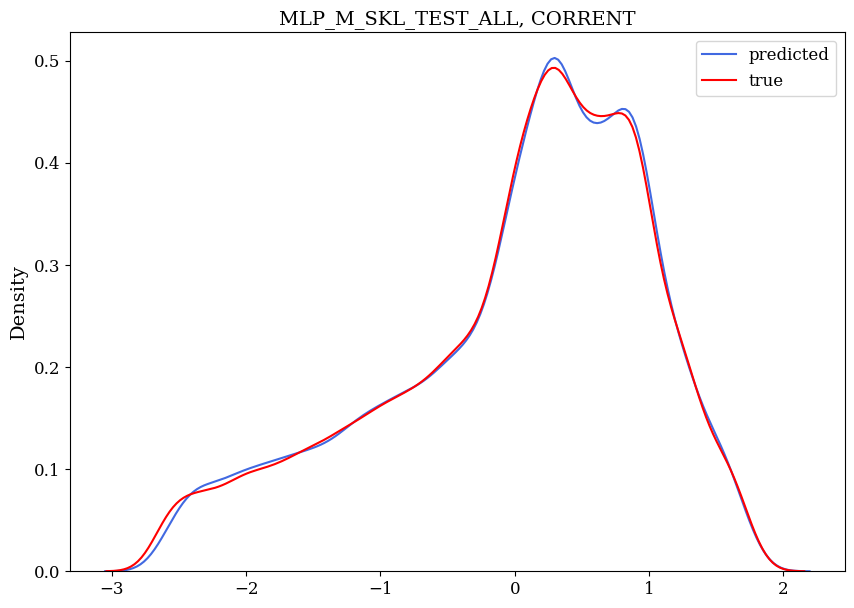

In [57]:
kde_plot_multi_output_regression_results(y_test_pred_sc, yte_sc, variables, "MLP_M_SKL_TEST_ALL", "MLP_M_SKL_TEST_ALL")

## Multi-layer Perceptron for Regression using Keras

Use test set and evaluate()

In [58]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

E0000 00:00:1779886277.006559   14842 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779886277.006994   14892 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779886277.021531   14842 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Single-output models

In [59]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(100, activation="relu", input_shape=X_train_sc.shape[1:]),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1)
])

/home/eduarda/Repos/jupyter_ic/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Predicting TPHL

In [60]:
K.clear_session()
model.compile(loss="mean_squared_error", optimizer="adam")
history = model.fit(X_train_sc, y_train_sc['tphl'], epochs=500, batch_size=32, validation_data=(X_val_sc, y_val_sc['tphl']),
                    shuffle=True, callbacks=[early_stop])

Epoch 1/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0286 - val_loss: 0.0015
Epoch 2/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0011 - val_loss: 5.1295e-04
Epoch 4/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 8.0592e-04 - val_loss: 6.0175e-04
Epoch 5/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 6.9427e-04 - val_loss: 0.0042
Epoch 6/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6.2225e-04 - val_loss: 7.9888e-04
Epoch 7/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 6.5197e-04 - val_loss: 0.0016
Epoch 8/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 5.0789e-04 - val_loss: 2.2339e-04
Epoch 9/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 5.0688e-04 - val_loss: 0.0019
Epoch 10/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 4.7215e-04 - val_loss: 4.7558e-04
Epoch 11/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - los

In [61]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc['tphl'], ypred_sc)
rmse = root_mean_squared_error(y_val_sc['tphl'], ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step
clf: ANN, rmse: 0.010086535009517053
clf: ANN, mse: 0.00010173818849821318


In [62]:
r2 = r2_score(y_val_sc['tphl'], ypred_sc)
print(f'R²: {r2}')

R²: 0.9998985984269424


In [63]:
score(model, X_val_sc, y_val_sc['tphl'], 'mlp_S_K', 'tphl', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 496us/step


{'r2': 0.9998985984269424,
 'rmse': 0.010086535009517053,
 'mse': 0.00010173818849821318}

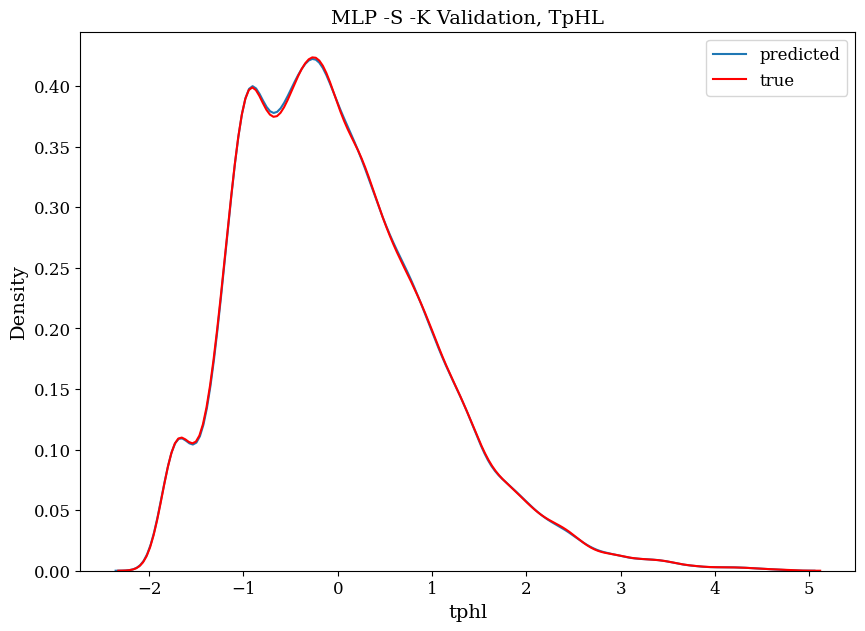

In [64]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=ypred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -K Validation, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_K_VAL_TPHL.png")
plt.show()
plt.close()

#### Predicting TPLH

In [65]:
K.clear_session()
model.compile(loss="mean_squared_error", optimizer="adam")
history = model.fit(X_train_sc, y_train_sc['tplh'], epochs=500, batch_size=32, validation_data=(X_val_sc, y_val_sc['tplh']),
                    shuffle=True, callbacks=[early_stop])

Epoch 1/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0467 - val_loss: 0.0011
Epoch 2/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0010 - val_loss: 9.3818e-04
Epoch 3/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0010 - val_loss: 8.9414e-04
Epoch 4/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 9.6473e-04 - val_loss: 8.6236e-04
Epoch 5/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 9.4804e-04 - val_loss: 0.0011
Epoch 6/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 9.1635e-04 - val_loss: 8.2357e-04
Epoch 7/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 8.9331e-04 - val_loss: 8.3318e-04
Epoch 8/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 8.8685e-04 - val_loss: 8.2525e-04
Epoch 9/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 8.7395e-04 - val_loss: 9.6072e-04
Epoch 10/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 8.8059e-04 - val_loss: 0.0010
Epoch 11/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/st

In [66]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc['tplh'], ypred_sc)
rmse = root_mean_squared_error(y_val_sc['tplh'], ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step
clf: ANN, rmse: 0.03267436031271691
clf: ANN, mse: 0.0010676138218452496


In [67]:
r2 = r2_score(y_val_sc['tplh'], ypred_sc)

print(f'R²: {r2}')

R²: 0.9989038114895143


In [68]:
score(model, X_val_sc, y_val_sc['tplh'], 'mlp_S_K', 'tplh', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 511us/step


{'r2': 0.9989038114895143,
 'rmse': 0.03267436031271691,
 'mse': 0.0010676138218452496}

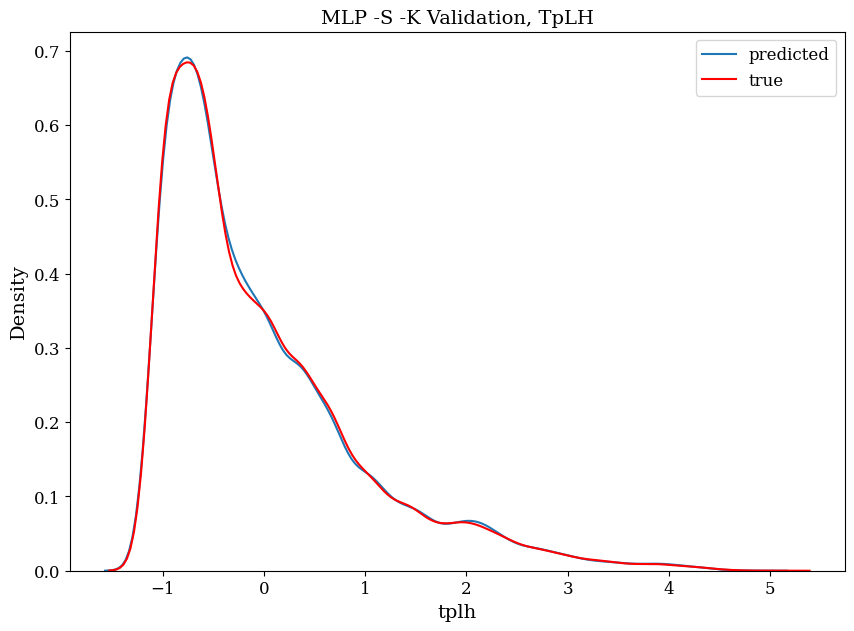

In [69]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=ypred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -K Validation, TpLH')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_K_VAL_TPLH.png")
plt.show()
plt.close()

#### Predicting Energy

In [70]:
K.clear_session()
model.compile(loss="mean_squared_error", optimizer="adam")
history = model.fit(X_train_sc, y_train_sc['energy'], epochs=500, batch_size=32, validation_data=(X_val_sc, y_val_sc['energy']),
                    shuffle=True, callbacks=[early_stop])

Epoch 1/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0369 - val_loss: 0.0032
Epoch 2/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0027 - val_loss: 0.0024
Epoch 3/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 4/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 5/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 6/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 7/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 8/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 9/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 10/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 11/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 12/500
2007/2

In [71]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc['energy'], ypred_sc)
rmse = root_mean_squared_error(y_val_sc['energy'], ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step
clf: ANN, rmse: 0.05667792404599431
clf: ANN, mse: 0.0032123870741634997


In [72]:
r2 = r2_score(y_val_sc['energy'], ypred_sc)
print(f'R²: {r2}')

R²: 0.9967834415611609


In [73]:
score(model, X_val_sc, y_val_sc['energy'], 'mlp_S_K', 'corrent', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step


{'r2': 0.9967834415611609,
 'rmse': 0.05667792404599431,
 'mse': 0.0032123870741634997}

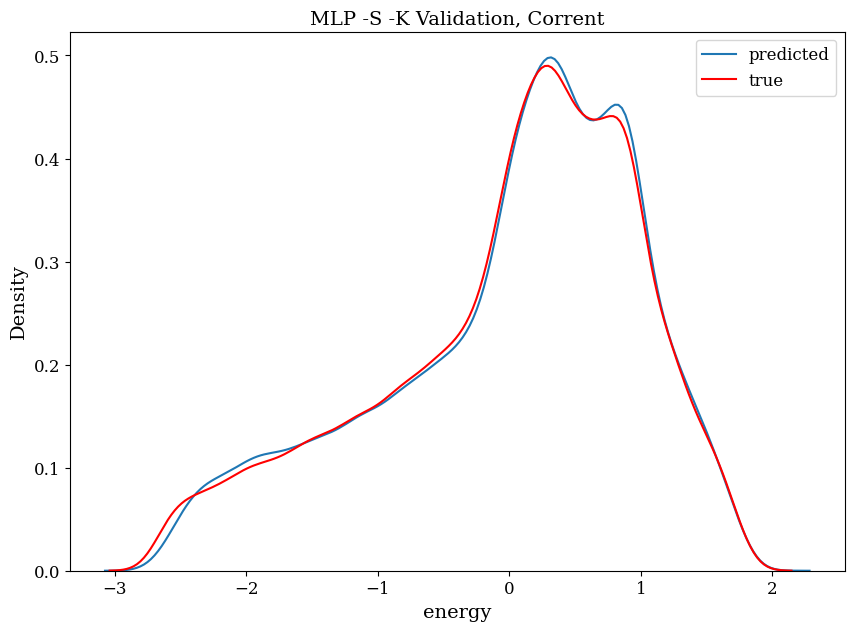

In [74]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=ypred_sc, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['energy'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -K Validation, Corrent')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_K_VAL_CORRENT.png")
plt.show()
plt.close()

### Multi-output model

In [75]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(100, activation="relu", input_shape=X_train_sc.shape[1:]),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(3)
])

K.clear_session()
model.compile(loss="mean_squared_error", optimizer="adam")
history = model.fit(X_train_sc, y_train_sc, epochs=500, batch_size=32, validation_data=(X_val_sc, y_val_sc), 
                    shuffle=True, callbacks=[early_stop])


/home/eduarda/Repos/jupyter_ic/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0429 - val_loss: 0.0029
Epoch 2/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 3/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 4/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 5/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 6/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 7/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 8/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 10/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 11/500
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 12/500
2007/2

In [76]:
ypred_sc = model.predict(X_val_sc)
mse = mean_squared_error(y_val_sc, ypred_sc)
rmse = root_mean_squared_error(y_val_sc, ypred_sc)
print(f'clf: ANN, rmse: {rmse}')
print(f'clf: ANN, mse: {mse}')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step
clf: ANN, rmse: 0.05319090560078621
clf: ANN, mse: 0.002885818714275956


In [77]:
r2 = r2_score(y_val_sc, ypred_sc)

print(f'R²: {r2}')

R²: 0.99709552526474


In [78]:
score(model, X_val_sc, y_val_sc, 'mlp_M_K', 'all', 'val')

989/989 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step


{'r2': 0.99709552526474,
 'rmse': 0.05319090560078621,
 'mse': 0.002885818714275956}

In [79]:
variables = ['TPHL', 'TPLH', 'CORRENT']
#scatter_plot_multi_output_regression_results(ypred_sc, y_val_sc, variables, "MLP_M_K_VALL_ALL_SCATTER", "MLP_M_K_VALL_ALL_SCATTER")

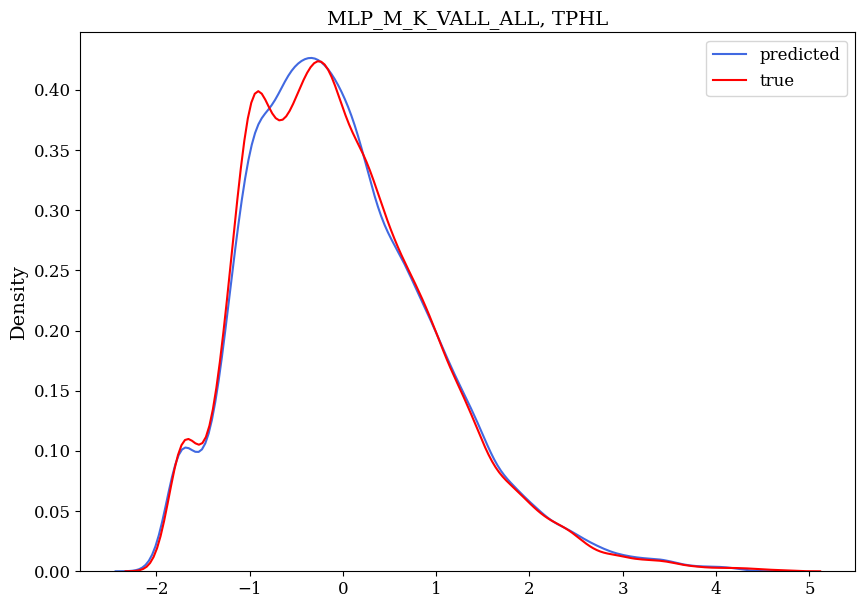

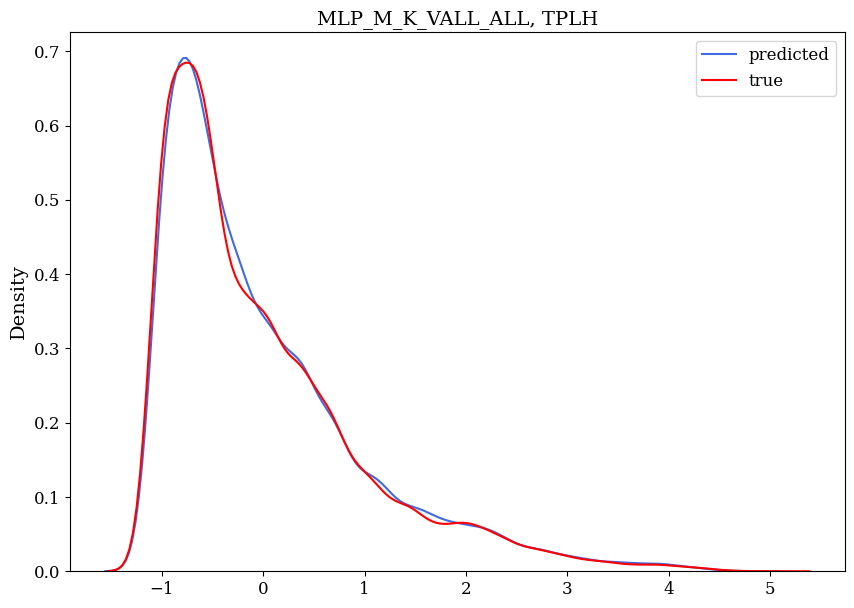

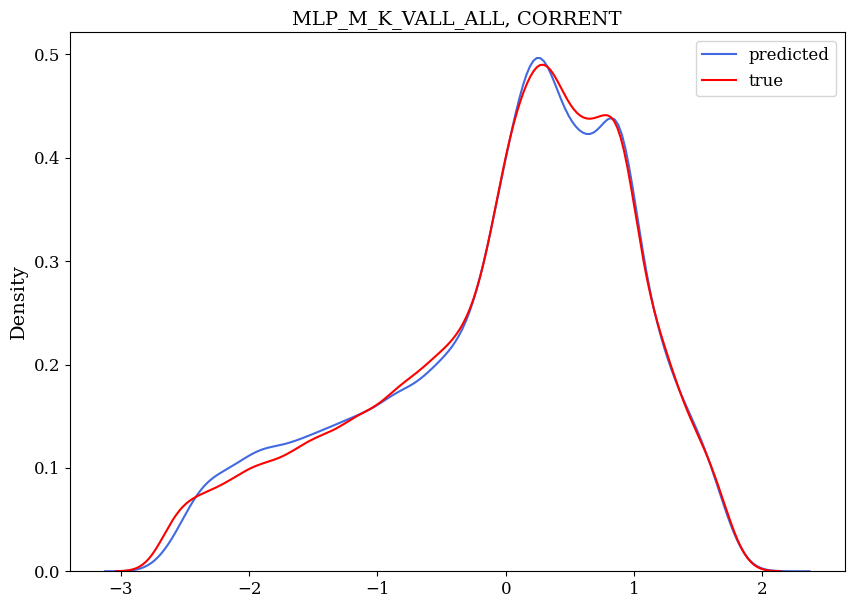

In [80]:
kde_plot_multi_output_regression_results(ypred_sc, y_val_sc, variables, "MLP_M_K_VAL_ALL", "MLP_M_K_VALL_ALL")

## Results

In [81]:
results = pd.DataFrame.from_dict(scores, orient='index')
results.index.names = ['target', 'model', 'set']

path = os.path.join('../../../../../outputs/CMOS/32nm/NOT/MLP_Regressor', 'results_mlps')

from datetime import datetime

current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
path_with_time = f"{path}_{current_time}.csv"
results.to_csv(path_with_time, index_label='target_name')

results

r2      rmse       mse
target    model   set                               
mlp_S_SKL tphl    val   0.999675  0.018046  0.000326
                  test  0.999657  0.018645  0.000348
          tplh    val   0.999273  0.026609  0.000708
                  test  0.999269  0.027004  0.000729
          corrent val   0.998177  0.042669  0.001821
                  test  0.998194  0.042582  0.001813
mlp_M_SKL all     val   0.998644  0.035020  0.001348
                  test  0.998632  0.035425  0.001373
mlp_S_K   tphl    val   0.999899  0.010087  0.000102
          tplh    val   0.998904  0.032674  0.001068
          corrent val   0.996783  0.056678  0.003212
mlp_M_K   all     val   0.997096  0.053191  0.002886